# Análisis de Datos para Ciberseguridad
### **Trabajo práctico 2**

**Ph. D. Saúl Calderón Ramírez**  
Instituto Tecnológico de Costa Rica  
Escuela de Ingeniería en Computación, Programa de Ciencias de Datos  
Pattern Recognition and MAchine Learning Group (PARMA-Group)

| Daniel Araya | Andrés Mora | Alvaro |
| :--             | :--         | :--                    |
| *Carnet: 2025800352* | *Carnet: 2013241401* | Carnet: *2025800357* |


# Imports and data loading

In [ ]:
#!pip install tensorflow
!pip install pandas
!pip install matplotlib
!pip install numpy
!pip install seaborn
!pip install torch
!pip install scikit-learn
#!pip install
!pip install optuna


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F


In [ ]:
#tomado de https://www.kaggle.com/code/wailinnoo/intrusion-detection-system-using-kdd99-dataset
import pandas as pd
from tensorflow.keras.utils import get_file

try:
    path = get_file('kddcup.data_10_percent.gz', origin='http://kdd.ics.uci.edu/databases/kddcup99/kddcup.data_10_percent.gz')
except:
    print('Error downloading')
    raise

print(path)

# This file is a CSV, just no CSV extension or headers
# Download from: http://kdd.ics.uci.edu/databases/kddcup99/kddcup99.html
pd_data_frame = pd.read_csv(path, header=None)

# The CSV file has no column heads, so add them
pd_data_frame.columns = [
    'duration',
    'protocol_type',
    'service',
    'flag',
    'src_bytes',
    'dst_bytes',
    'land',
    'wrong_fragment',
    'urgent',
    'hot',
    'num_failed_logins',
    'logged_in',
    'num_compromised',
    'root_shell',
    'su_attempted',
    'num_root',
    'num_file_creations',
    'num_shells',
    'num_access_files',
    'num_outbound_cmds',
    'is_host_login',
    'is_guest_login',
    'count',
    'srv_count',
    'serror_rate',
    'srv_serror_rate',
    'rerror_rate',
    'srv_rerror_rate',
    'same_srv_rate',
    'diff_srv_rate',
    'srv_diff_host_rate',
    'dst_host_count',
    'dst_host_srv_count',
    'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate',
    'dst_host_srv_serror_rate',
    'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate',
    'outcome'
]

#describe the dataset
#transform nominal features using a one hot vector encoding
pd_data_frame.describe()




# Preprocessing and  Dummy encoding transformation

Attacks fall into four main categories:






1.   DOS: denial-of-service, e.g. syn flood;
2.   R2L: unauthorized access from a remote machine, e.g. guessing password;

3. U2R:  unauthorized access to local superuser (root) privileges, e.g., various ``buffer overflow'' attacks;

4. probing: surveillance and other probing, e.g., port scanning.


It is important to note that the test data is not from the same probability distribution as the training data, and it includes specific attack types not in the training data.  This makes the task more realistic.  Some intrusion experts believe that most novel attacks are variants of known attacks and the "signature" of known attacks can be sufficient to catch novel variants.  The datasets contain a total of 24 training attack types, with an additional 14 types in the test data only.

Neptune is the most frequent attack in the dataset, consisting in a type of denial-of-service (DoS) attack overwhelming systems with SYN requests (synchronize request, is a type of network packet used in the TCP handshake to initiate a connection between a client and a server).

**In this work we will focus in the detection of backdrop attacks**.

In [ ]:
# For now, just drop NA's (rows with missing values), in case there are
pd_data_frame.dropna(inplace=True,axis=1)

# Checkng for DUPLICATE values
pd_data_frame.drop_duplicates(keep='first', inplace = True)
print(pd_data_frame.describe())
filtered_df = pd_data_frame


In [ ]:
# distribution of the attack categories (outcome)
# Exploratory data analysis
import matplotlib.pyplot as plt
from matplotlib.pyplot import *

plt.figure(figsize=(15,7))
class_distribution = pd_data_frame['outcome'].value_counts()
class_distribution.plot(kind='bar')
plt.xlabel('Class')
plt.ylabel('Data points per Class')
plt.title('Distribution of yi in train data')
plt.grid()
plt.show()

#normal and neptune are the more prominent classes

In [ ]:
list_nominal_features = ["flag", "protocol_type", "service"]

# Apply one-hot encoding to the nominal features
df_encoded = pd.get_dummies(filtered_df, columns=list_nominal_features)

# Convert boolean columns (from one-hot encoding) to integers (0 or 1) in df_encoded
for col in df_encoded.columns:
    if df_encoded[col].dtype == 'bool':
        df_encoded[col] = df_encoded[col].astype(int)

# Display the first few rows of the modified DataFrame to verify
print("DataFrame with boolean columns converted to integers:")
display(df_encoded.describe())
print("Columns after nominal attributes encoded: ")
for i in df_encoded.columns:
  print(i)


## Split data


Split the `pd_data_frame` into training, validation, and test sets using `train_test_split` from `sklearn.model_selection`.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# create the label codifier
label_encoder = LabelEncoder()



# Aplicar el codificador a la columna 'outcome'
df_encoded['outcome'] = label_encoder.fit_transform(df_encoded['outcome'])


y = df_encoded['outcome'].values.astype('float')
print(" y ", y[0])
x_columns = df_encoded.columns.drop(['outcome'])
x = df_encoded[x_columns].values.astype('float')

In [ ]:
from sklearn.model_selection import train_test_split
#split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# Standardize the data (relevant for neural networks)
Ensure that all the variables have mu = 0 and sigma = 1

In [ ]:
from sklearn.preprocessing import StandardScaler



# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
x_train_scaled = scaler.fit_transform(x_train)

# Transform the test data using the fitted scaler
x_test_scaled = scaler.transform(x_test)

## 1. (30 puntos) Implementacion de un *`árbol`* de decision y random forests para clasificar todos los tipos de ataques (scikit learn)

### 1. Genere una función split_dataset la cual divida los datos en  entrenamiento (70 %), validación (15 %) y prueba (15 %).



In [ ]:
from typing import Tuple
import numpy as np
from sklearn.model_selection import train_test_split

def split_dataset(
    X,
    y,
    train_size: float = 0.70,
    val_size: float = 0.15,
    test_size: float = 0.15,
    stratify: bool = True,
    random_state: int = 42
) -> Tuple:
    """
    Divide X, y en train/val/test con proporciones dadas.
    - Mantiene la distribución de clases (stratify=True).
    - Hace split en dos pasos: (train+val) vs test, y luego train vs val.
    """
    total = train_size + val_size + test_size
    if not np.isclose(total, 1.0):
        raise ValueError("train_size + val_size + test_size debe sumar 1.0")

    strat_all = y if stratify else None

    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=strat_all,
        shuffle=True,
        random_state=random_state
    )

    val_rel = val_size / (train_size + val_size)
    strat_temp = y_temp if stratify else None

    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp,
        test_size=val_rel,
        stratify=strat_temp,
        shuffle=True,
        random_state=random_state
    )

    return X_train, X_val, X_test, y_train, y_val, y_test


In [ ]:
X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(x, y, random_state=42)

n = len(y)
print({
    "train": (len(y_train), len(y_train)/n),
    "val":   (len(y_val),   len(y_val)/n),
    "test":  (len(y_test),  len(y_test)/n),
})


In [ ]:
from sklearn.preprocessing import StandardScaler

def standardize_by_train(X_train, X_val, X_test, with_mean=True, with_std=True):
    """
    Ajusta StandardScaler SOLO con X_train y transforma X_train, X_val y X_test.
    Devuelve: X_train_scaled, X_val_scaled, X_test_scaled, scaler
    """
    scaler = StandardScaler(with_mean=with_mean, with_std=with_std)
    scaler.fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_val_s   = scaler.transform(X_val)
    X_test_s  = scaler.transform(X_test)
    return X_train_s, X_val_s, X_test_s, scaler

X_train_scaled, X_val_scaled, X_test_scaled, scaler = standardize_by_train(
    X_train, X_val, X_test
)


### 2. (15 puntos) Entrene un arbol de decision (de scikitlearn) para clasificar los ataques en todas las categorias originales del dataset:

#### a) Optimice la profundidad máxima, cantidad mínima de observaciones por partición y el criterio de pureza usando optuna o weights and biases. Documente los rangos de cada hiper-parametro y justifique la decisión por cada uno. Muestre los gráficos de ese proceso de optimización y seleccione las 3 mejores arquitecturas.

In [ ]:
%pip install -q optuna

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
import optuna

seed = 42
np.random.seed(seed)

def macro_fpr(y_true, y_pred):
    """
    Tasa de falsos positivos macro-promediada.
    Para cada clase: FPR_i = FP_i / (FP_i + TN_i)
    Macro-FPR = promedio de FPR_i sobre todas las clases
    """
    cm = confusion_matrix(y_true, y_pred, labels=np.unique(y_true))
    FP = cm.sum(axis=0) - np.diag(cm)  # Falsos Positivos
    TN = cm.sum() - (cm.sum(axis=1) + cm.sum(axis=0) - np.diag(cm))  # Verdaderos Negativos
    fpr_per_class = FP / (FP + TN + 1e-12)
    return np.mean(fpr_per_class)


In [ ]:
def objective(trial):
    max_depth = trial.suggest_categorical("max_depth", [None] + list(range(3, 41)))
    min_samples_split = trial.suggest_int("min_samples_split", 2, 64)
    criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])

    clf = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        criterion=criterion,
        random_state=seed
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)
    return f1_score(y_val, y_pred, average="macro")

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=seed)
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

[I 2025-09-22 02:39:16,859] A new study created in memory with name: no-name-20ed91b6-4a23-4256-8c41-276374d16a24


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-09-22 02:39:17,804] Trial 0 finished with value: 0.6742408017302508 and parameters: {'max_depth': 13, 'min_samples_split': 29, 'criterion': 'entropy'}. Best is trial 0 with value: 0.6742408017302508.
[I 2025-09-22 02:39:21,127] Trial 1 finished with value: 0.682984620922139 and parameters: {'max_depth': 29, 'min_samples_split': 41, 'criterion': 'gini'}. Best is trial 1 with value: 0.682984620922139.
[I 2025-09-22 02:39:22,829] Trial 2 finished with value: 0.680126886322745 and parameters: {'max_depth': 30, 'min_samples_split': 8, 'criterion': 'entropy'}. Best is trial 1 with value: 0.682984620922139.
[I 2025-09-22 02:39:25,440] Trial 3 finished with value: 0.6524188266285386 and parameters: {'max_depth': 30, 'min_samples_split': 54, 'criterion': 'gini'}. Best is trial 1 with value: 0.682984620922139.
[I 2025-09-22 02:39:26,874] Trial 4 finished with value: 0.6835676658803403 and parameters: {'max_depth': 12, 'min_samples_split': 43, 'criterion': 'entropy'}. Best is trial 4 with

=== Historial de Optimización ===
Error generando Historial de Optimización: plot_optimization_history() got an unexpected keyword argument 'ax'
=== Importancia de Parámetros ===
Error generando Importancia de Parámetros: plot_param_importances() got an unexpected keyword argument 'ax'
=== Gráfico de Contorno ===
Error generando Gráfico de Contorno: plot_contour() got an unexpected keyword argument 'ax'

=== GRÁFICAS PERSONALIZADAS ===


/tmp/ipython-input-3279919869.py:23: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  result = plot_func(study, ax=ax)
/tmp/ipython-input-3279919869.py:23: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  result = plot_func(study, ax=ax)
/tmp/ipython-input-3279919869.py:21: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  result = plot_func(study, ax=ax, **kwargs)


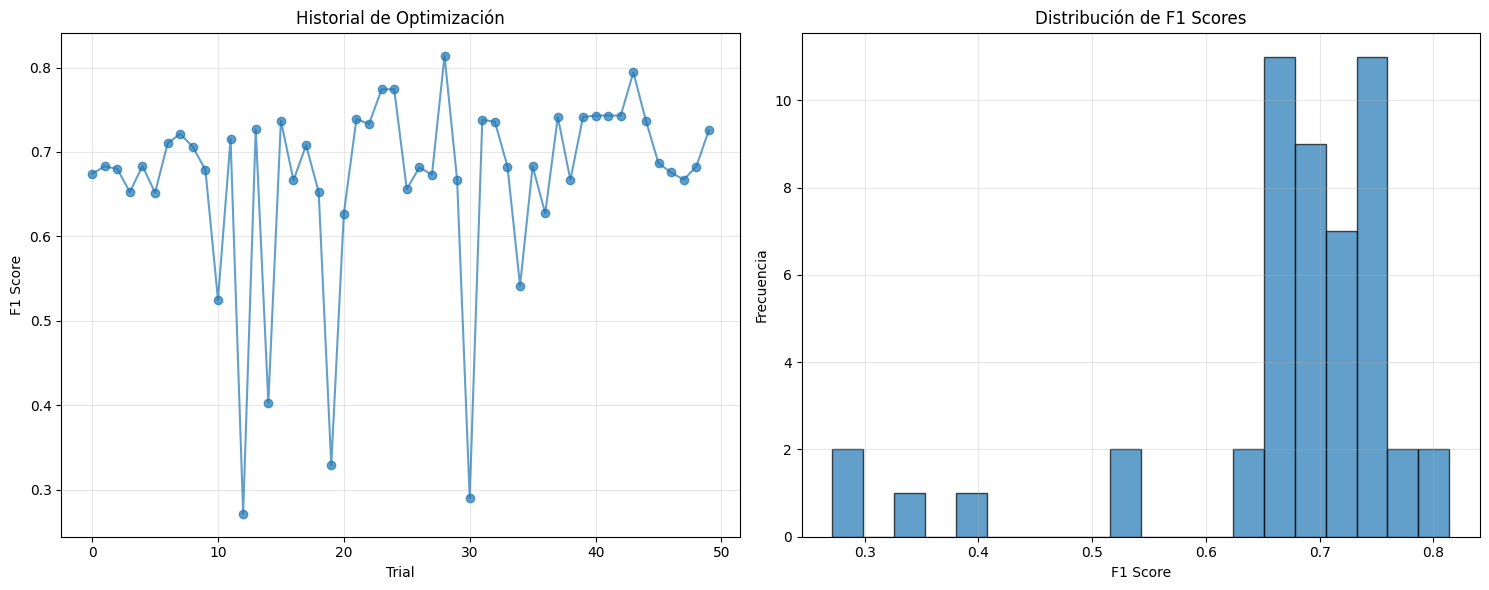

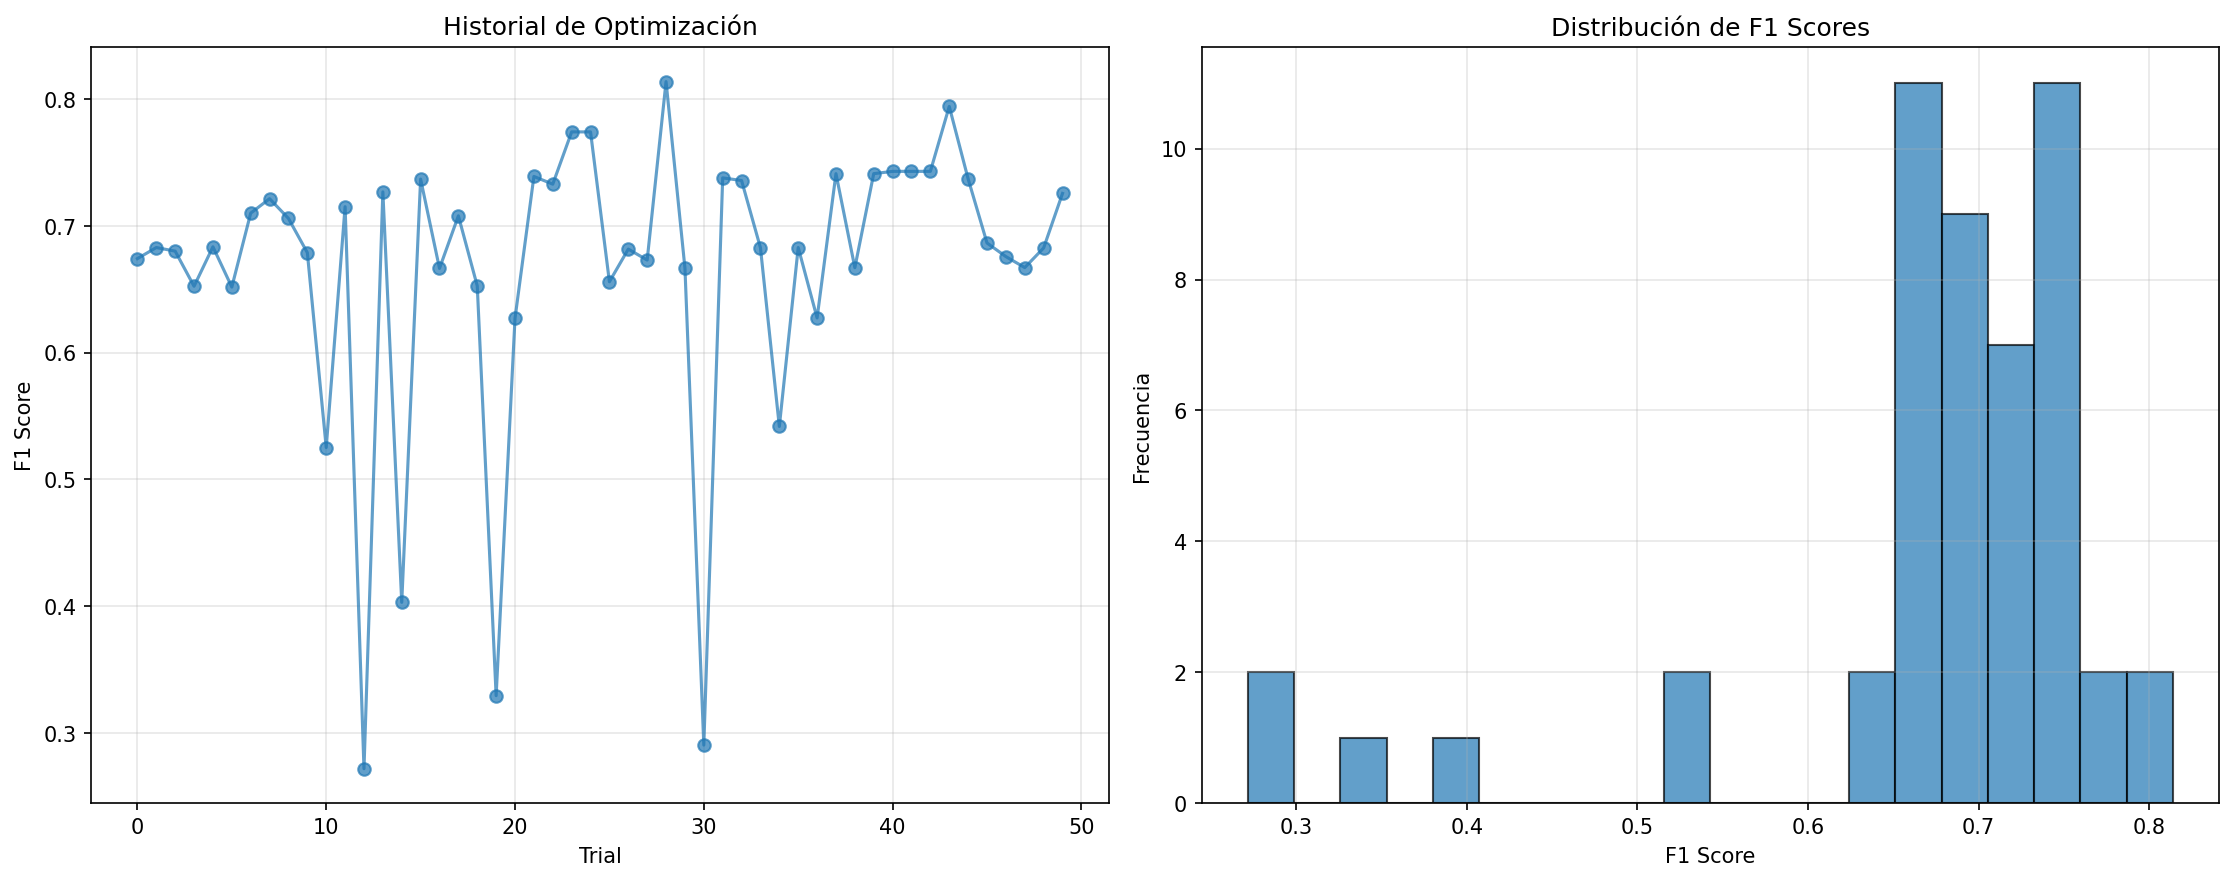


=== RESULTADOS ===
TOP 10 RESULTADOS:


,trial_number,value_f1_val,max_depth,min_samples_split,criterion
28,28,0.813925,17.0,6,gini
43,43,0.794317,22.0,7,gini
24,24,0.774235,21.0,8,gini
23,23,0.774235,21.0,8,gini
42,42,0.743094,22.0,2,gini
41,41,0.743094,22.0,2,gini
40,40,0.743094,22.0,2,gini
37,37,0.741284,39.0,12,gini
39,39,0.741284,39.0,12,gini
21,21,0.739078,21.0,11,gini



TOP 3 MEJORES:


,trial_number,value_f1_val,max_depth,min_samples_split,criterion
0,28,0.813925,17.0,6,gini
1,43,0.794317,22.0,7,gini
2,24,0.774235,21.0,8,gini



Configuración de los mejores modelos:
Modelo #1: {'max_depth': 17.0, 'min_samples_split': 6, 'criterion': 'gini'}
Modelo #2: {'max_depth': 22.0, 'min_samples_split': 7, 'criterion': 'gini'}
Modelo #3: {'max_depth': 21.0, 'min_samples_split': 8, 'criterion': 'gini'}


In [26]:
import matplotlib.pyplot as plt
from IPython.display import display, Image
import io
import base64
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_contour
)

def force_show_plot(plot_func, study, title, **kwargs):
    """Función que fuerza la visualización de gráficas de Optuna"""
    print(f"=== {title} ===")

    try:
        # Crear figura explícitamente
        fig, ax = plt.subplots(figsize=(12, 8))

        # Generar gráfica
        if 'params' in kwargs:
            result = plot_func(study, ax=ax, **kwargs)
        else:
            result = plot_func(study, ax=ax)

        # Configurar y mostrar
        plt.tight_layout()

        # Método 1: plt.show()
        plt.show()

        # Método 2: Guardar como imagen y mostrar
        filename = title.lower().replace(' ', '_') + '.png'
        fig.savefig(filename, dpi=150, bbox_inches='tight')
        display(Image(filename))

        plt.close(fig)
        return True

    except Exception as e:
        print(f"Error generando {title}: {e}")
        plt.close('all')
        return False

# Configurar matplotlib
%matplotlib inline
plt.style.use('default')

# Generar gráficas
success1 = force_show_plot(
    plot_optimization_history,
    study,
    "Historial de Optimización"
)

success2 = force_show_plot(
    plot_param_importances,
    study,
    "Importancia de Parámetros"
)

success3 = force_show_plot(
    plot_contour,
    study,
    "Gráfico de Contorno",
    params=['max_depth', 'min_samples_split']
)

# Si las gráficas de Optuna fallan, crear gráficas personalizadas
if not all([success1, success2, success3]):
    print("\n=== GRÁFICAS PERSONALIZADAS ===")

    # Extraer datos
    trials_data = []
    for trial in study.trials:
        if trial.value is not None:
            trials_data.append({
                'trial': trial.number,
                'value': trial.value,
                'max_depth': trial.params.get('max_depth'),
                'min_samples_split': trial.params.get('min_samples_split'),
                'criterion': trial.params.get('criterion')
            })

    df_trials = pd.DataFrame(trials_data)

    # Gráfica personalizada de historial
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Historial de optimización
    ax1.plot(df_trials['trial'], df_trials['value'], 'o-', alpha=0.7)
    ax1.set_xlabel('Trial')
    ax1.set_ylabel('F1 Score')
    ax1.set_title('Historial de Optimización')
    ax1.grid(True, alpha=0.3)

    # Distribución de F1 scores
    ax2.hist(df_trials['value'], bins=20, alpha=0.7, edgecolor='black')
    ax2.set_xlabel('F1 Score')
    ax2.set_ylabel('Frecuencia')
    ax2.set_title('Distribución de F1 Scores')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('custom_optimization_plots.png', dpi=150, bbox_inches='tight')
    plt.show()
    display(Image('custom_optimization_plots.png'))

# Mostrar resultados tabulares
print("\n=== RESULTADOS ===")
trials = [
    {
        "trial_number": t.number,
        "value_f1_val": t.value,
        **t.params
    }
    for t in study.trials if t.value is not None
]
df_trials = pd.DataFrame(trials).sort_values("value_f1_val", ascending=False)

print("TOP 10 RESULTADOS:")
display(df_trials.head(10))

print("\nTOP 3 MEJORES:")
top3 = df_trials.head(3).reset_index(drop=True)
display(top3)

top3_params = [
    row.drop(labels=["trial_number", "value_f1_val"]).to_dict()
    for _, row in top3.iterrows()
]

print("\nConfiguración de los mejores modelos:")
for i, params in enumerate(top3_params, 1):
    print(f"Modelo #{i}: {params}")

plt.close('all')

In [27]:
import pandas as pd
def _concat(a, b):
    return pd.concat([a,b], axis=0) if hasattr(a, "iloc") else np.concatenate([a,b], axis=0)

sorted_trials = sorted([t for t in study.trials if t.value is not None], key=lambda t: t.value, reverse=True)[:3]
top3_params = [t.params for t in sorted_trials]

results = []
X_tr = _concat(X_train, X_val)
y_tr = _concat(y_train, y_val)

for i, params in enumerate(top3_params, 1):
    clf = DecisionTreeClassifier(**params, random_state=seed)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_test)
    results.append({
        "rank": i,
        "params": params,
        "acc": accuracy_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "fpr_macro": macro_fpr(y_test, y_pred)
    })

pd.DataFrame(results)


,rank,params,acc,f1_macro,fpr_macro
0,1,"{'max_depth': 17, 'min_samples_split': 6, 'cri...",0.998672,0.746760,0.000124
1,2,"{'max_depth': 22, 'min_samples_split': 7, 'cri...",0.998718,0.741323,0.000110
2,3,"{'max_depth': 21, 'min_samples_split': 8, 'cri...",0.998672,0.668289,0.000110


### Justificación de rangos de hiperparámetros (Decision Tree + Optuna)

- **`max_depth`** ∈ {None} ∪ [3, 40]:  
  Se exploran árboles desde muy superficiales hasta profundos. Incluir `None` permite crecer hasta pureza, capturando interacciones complejas (riesgo de sobreajuste). El rango 3–40 busca un compromiso entre capacidad y generalización dada la alta cardinalidad tras el one-hot (e.g., `service`, `protocol_type`, `flag`) y el desbalance de clases de KDD’99.

- **`min_samples_split`** ∈ [2, 64]:  
  Controla la granularidad y actúa como regularizador. Valores mayores (p.ej., ≥16, ≥32) ayudan a evitar splits espurios sobre ruido y estabilizan el árbol en datasets grandes/desbalanceados; el límite 64 ofrece poda efectiva sin forzar infra-ajuste.

- **`criterion`** ∈ {`gini`, `entropy`}:  
  Ambas medidas son estándar. Dado que el objetivo es **F1-macro** (sensibilidad a clases minoritarias), se deja a Optuna decidir qué criterio favorece mejor el equilibrio entre clases.


#### b) Compare las tres mejores arquitecturas, para al menos 10 corridas diferentes (particiones), el F1-score promedio para todas las clases y la tasa de falsos positivos promedio para todas las clases, presen- te medias y desviaciones estandar usando la particion de prueba. Comente los resultados.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

if 'top3_params' not in globals():
    trials = [
        {"trial_number": t.number, "value_f1_val": t.value, **t.params}
        for t in study.trials if t.value is not None
    ]
    df_trials = pd.DataFrame(trials).sort_values("value_f1_val", ascending=False)
    top3 = df_trials.head(3).reset_index(drop=True)
    top3_params = [
        row.drop(labels=["trial_number", "value_f1_val"]).to_dict()
        for _, row in top3.iterrows()
    ]

summary_rows = []
all_runs_rows = []

num_runs = 10
partition_seeds = list(range(num_runs))

for m_idx, params in enumerate(top3_params, start=1):
    f1_scores = []
    fpr_scores = []

    for i, rs in enumerate(partition_seeds):
        X_train_run, X_val_run, X_test_run, y_train_run, y_val_run, y_test_run = split_dataset(x, y, random_state=rs)

        X_train_full = np.concatenate([X_train_run, X_val_run], axis=0)
        y_train_full = np.concatenate([y_train_run, y_val_run], axis=0)

        clf = DecisionTreeClassifier(**params, random_state=rs)
        clf.fit(X_train_full, y_train_full)

        y_pred_test = clf.predict(X_test_run)

        f1  = f1_score(y_test_run, y_pred_test, average="macro")
        fpr = macro_fpr(y_test_run, y_pred_test)

        f1_scores.append(f1)
        fpr_scores.append(fpr)

        all_runs_rows.append({
            "model_rank": m_idx,
            "run": i + 1,
            "max_depth": params.get("max_depth", None),
            "min_samples_split": params.get("min_samples_split", None),
            "criterion": params.get("criterion", None),
            "f1_macro": f1,
            "fpr_macro": fpr
        })

    summary_rows.append({
        "model_rank": m_idx,
        "max_depth": params.get("max_depth", None),
        "min_samples_split": params.get("min_samples_split", None),
        "criterion": params.get("criterion", None),
        "f1_macro_mean": np.mean(f1_scores),
        "f1_macro_std":  np.std(f1_scores),
        "fpr_macro_mean": np.mean(fpr_scores),
        "fpr_macro_std":  np.std(fpr_scores),
    })

df_runs = pd.DataFrame(all_runs_rows)
df_summary = pd.DataFrame(summary_rows)

df_summary = df_summary.sort_values("f1_macro_mean", ascending=False).reset_index(drop=True)

display(df_summary)
display(df_runs.head())


### 3. (15 puntos) Usando tambien la libreria scikit learn entrene un random forest.

#### a) Optimice con optuna o weights and biases la cantidad de arboles del random forest . Defina el rango de numero de arboles de decision de forma justificada.

In [ ]:
%pip install -q optuna

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import f1_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import optuna

seed = 42
np.random.seed(seed)

def objective_rf(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 800, step=25)

    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=seed,
        n_jobs=-1,
        bootstrap=True,
        max_depth=None,
        criterion="gini"
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)
    return f1_score(y_val, y_pred, average="macro")

study_rf = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=seed)
)
study_rf.optimize(objective_rf, n_trials=30, show_progress_bar=True)

from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice
)
fig1 = plot_optimization_history(study_rf); plt.tight_layout(); plt.show()
fig2 = plot_param_importances(study_rf);    plt.tight_layout(); plt.show()
fig3 = plot_slice(study_rf);                plt.tight_layout(); plt.show()

trials_rf = [
    {"trial_number": t.number, "f1_val": t.value, **t.params}
    for t in study_rf.trials if t.value is not None
]
df_trials_rf = pd.DataFrame(trials_rf).sort_values("f1_val", ascending=False)
display(df_trials_rf.head(10))

top2_rf = df_trials_rf.head(2).reset_index(drop=True)
display(top2_rf)
top2_rf_params = [ {"n_estimators": int(row["n_estimators"])} for _, row in top2_rf.iterrows() ]

best_rf_params = study_rf.best_params
clf_best_rf = RandomForestClassifier(
    **best_rf_params, random_state=seed, n_jobs=-1, bootstrap=True, max_depth=None, criterion="gini"
)
X_tr_rf = np.concatenate([X_train, X_val], axis=0)
y_tr_rf = np.concatenate([y_train, y_val], axis=0)
clf_best_rf.fit(X_tr_rf, y_tr_rf)
y_pred_test_rf = clf_best_rf.predict(X_test)

print("Best RF params (val):", best_rf_params)
print("Test F1-macro (best on val):", f1_score(y_test, y_pred_test_rf, average="macro"))

### Justificación del rango de `n_estimators` (Random Forest)

- **Inferior (50):** por debajo de ~50 árboles, la varianza del ensamble suele ser alta y la estabilidad entre particiones disminuye. 50 ofrece un punto de partida razonable y acorta el tiempo de búsqueda inicial.
- **Superior (800):** el error OOB/validación en Random Forest típicamente **satura** entre ~200–500 árboles en datasets tabulares grandes. Más árboles mejoran marginalmente (ley de rendimientos decrecientes) pero **escala linealmente el costo**. Con KDD’99 (10% set con cientos de miles de muestras) 800 fija un techo que permite capturar el posible *plateau* sin hacer el tuning prohibitivo.
- **Paso (25):** balancea granularidad y costo computacional. Diferencias menores a ~25 árboles rara vez cambian F1-macro de forma significativa frente al ruido de la partición, pero multiplican ensayos.

> Nota: se mantiene el resto de hiperparámetros por defecto porque el **punto 3.a** exige **optimizar solamente** `n_estimators`. En 3.b compararemos las **dos mejores** configuraciones con ≥10 corridas, reportando medias y DE de F1-macro y FPR-macro.


#### b) Compare los 2 mejores random forests seleccionados por la herramienta, haciendo 10 corridas diferentes (particiones), el F1-score promedio para todas las clases y la tasa de falsos positivos promedio para todas las clases, presente medias y desviaciones estandar usando la particion de prueba. Comente los resultados

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

if 'top2_rf_params' not in globals():
    if 'study_rf' in globals():
        trials_rf = [
            {"trial_number": t.number, "f1_val": t.value, **t.params}
            for t in study_rf.trials if t.value is not None
        ]
        df_trials_rf = pd.DataFrame(trials_rf).sort_values("f1_val", ascending=False)
        top2_rf = df_trials_rf.head(2).reset_index(drop=True)
        top2_rf_params = [{"n_estimators": int(row["n_estimators"])} for _, row in top2_rf.iterrows()]
    else:
        raise RuntimeError("No se encuentran top2_rf_params ni study_rf. Ejecuta 3.a primero.")

num_runs = 10
seeds = list(range(num_runs))

summary_rows = []
runs_rows = []

for m_idx, p in enumerate(top2_rf_params, start=1):
    n_est = int(p["n_estimators"])
    f1s, fprs = [], []

    for run_i, rs in enumerate(seeds, start=1):
        X_train_run, X_val_run, X_test_run, y_train_run, y_val_run, y_test_run = split_dataset(x, y, random_state=rs)

        X_train_full = np.concatenate([X_train_run, X_val_run], axis=0)
        y_train_full = np.concatenate([y_train_run, y_val_run], axis=0)

        clf = RandomForestClassifier(
            n_estimators=n_est,
            random_state=rs,
            n_jobs=-1,
            bootstrap=True,
            max_depth=None,
            criterion="gini"
        )
        clf.fit(X_train_full, y_train_full)
        y_pred = clf.predict(X_test_run)

        f1  = f1_score(y_test_run, y_pred, average="macro")
        fpr = macro_fpr(y_test_run, y_pred)

        f1s.append(f1)
        fprs.append(fpr)

        runs_rows.append({
            "model_rank": m_idx,
            "run": run_i,
            "n_estimators": n_est,
            "f1_macro": f1,
            "fpr_macro": fpr
        })

    summary_rows.append({
        "model_rank": m_idx,
        "n_estimators": n_est,
        "f1_macro_mean": float(np.mean(f1s)),
        "f1_macro_std":  float(np.std(f1s)),
        "fpr_macro_mean": float(np.mean(fprs)),
        "fpr_macro_std":  float(np.std(fprs))
    })

df_runs_rf = pd.DataFrame(runs_rows)
df_summary_rf = pd.DataFrame(summary_rows).sort_values("f1_macro_mean", ascending=False).reset_index(drop=True)

display(df_summary_rf)
display(df_runs_rf.head())

best  = df_summary_rf.iloc[0]
second = df_summary_rf.iloc[1]

def pct(a, b):
    return 0.0 if b == 0 else 100.0 * (a - b) / b

delta_f1 = best["f1_macro_mean"] - second["f1_macro_mean"]
delta_f1_pct = pct(best["f1_macro_mean"], second["f1_macro_mean"])
delta_fpr = best["fpr_macro_mean"] - second["fpr_macro_mean"]
delta_fpr_pct = pct(best["fpr_macro_mean"], second["fpr_macro_mean"])

print("\n--- Comentario automático (3.b) ---")
print(f"Mejor RF: n_estimators={int(best['n_estimators'])} "
      f"→ F1-macro={best['f1_macro_mean']:.4f}±{best['f1_macro_std']:.4f}, "
      f"FPR-macro={best['fpr_macro_mean']:.6f}±{best['fpr_macro_std']:.6f}")
print(f"Segundo:  n_estimators={int(second['n_estimators'])} "
      f"→ F1-macro={second['f1_macro_mean']:.4f}±{second['f1_macro_std']:.4f}, "
      f"FPR-macro={second['fpr_macro_mean']:.6f}±{second['fpr_macro_std']:.6f}")

sig_hint = "no muestra una ventaja clara (|ΔF1| < 1×DE combinada)" \
           if abs(delta_f1) < (best['f1_macro_std'] + second['f1_macro_std'])/2 \
           else "muestra una ventaja consistente"

print(f"\nDiferencia: ΔF1={delta_f1:+.4f} ({delta_f1_pct:+.2f}%), "
      f"ΔFPR={delta_fpr:+.6f} ({delta_fpr_pct:+.2f}%).")
print(f"Interpretación: El modelo con {int(best['n_estimators'])} árboles {sig_hint}. "
      "Si la ganancia en F1 viene con FPR similar o menor, es preferible. "
      "Si F1 sube pero FPR aumenta de forma apreciable, considerar el trade-off según la aplicación.")


## 2. (30 puntos) Implementacion de una red neuronal para la clasificacion de todos los tipos de ataques (pytorch)

### 2.1 (10 puntos) Implemente la clase FCN la cual implemente una red de 4 capas en pytorch, y defina la mejor arquitectura posible según las restricciones del problema, de forma justificada. Justifique que funciones deactivación son las más pertinentes para el problema.

a) Use en tal arquitectura la cantidad de neuronas/capas que usted
desee, y como funciones de activacion, en las capas intermedias funciones de activacion ReLU, en la capa de salida la funcion de activacion softmax .

In [ ]:
# =========================
# Preparación de datos escalados para la red neuronal
# =========================

# Primero, asegurémonos de que tenemos los splits base
if 'X_train' not in globals():
    print("Creando splits de datos...")
    X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(x, y, random_state=42)

# Crear versiones escaladas usando la función ya definida
print("Escalando datos...")
X_train_scaled, X_val_scaled, X_test_scaled, scaler = standardize_by_train(
    X_train, X_val, X_test
)

print(f"Datos escalados creados:")
print(f"  X_train_scaled shape: {X_train_scaled.shape}")
print(f"  X_val_scaled shape: {X_val_scaled.shape}")
print(f"  X_test_scaled shape: {X_test_scaled.shape}")
print(f"  Número de clases: {len(np.unique(y_train))}")

In [ ]:
# =========================
# 2. Implementación de Red Neuronal (PyTorch)
# =========================

# Imports necesarios
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import optuna
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Configurar device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Seed para reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# =========================
# 2.1 Implementación de la clase FCN
# =========================

class FCN(nn.Module):
    """
    Red Neuronal Completamente Conectada (Fully Connected Network) para clasificación multiclase.

    Arquitectura justificada:
    - 4 capas como se requiere
    - Capas intermedias con ReLU (no linealidad, evita vanishing gradient)
    - Dropout para regularización (reduce overfitting en datasets desbalanceados)
    - BatchNorm para estabilizar entrenamiento
    - Softmax implícito en CrossEntropyLoss
    """

    def __init__(self, input_size, hidden_sizes, num_classes, dropout_rate=0.3):
        super(FCN, self).__init__()

        # Validación de arquitectura (4 capas)
        if len(hidden_sizes) != 2:
            raise ValueError("Esta implementación requiere exactamente 2 capas ocultas (4 capas totales)")

        self.input_size = input_size
        self.num_classes = num_classes

        # Capa 1: Input -> Hidden1
        self.fc1 = nn.Linear(input_size, hidden_sizes[0])
        self.bn1 = nn.BatchNorm1d(hidden_sizes[0])
        self.dropout1 = nn.Dropout(dropout_rate)

        # Capa 2: Hidden1 -> Hidden2
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.bn2 = nn.BatchNorm1d(hidden_sizes[1])
        self.dropout2 = nn.Dropout(dropout_rate)

        # Capa 3: Hidden2 -> Output
        self.fc3 = nn.Linear(hidden_sizes[1], num_classes)

        # Inicialización de pesos (Xavier/Glorot para ReLU)
        self._initialize_weights()

    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x):
        # Capa 1
        x = self.fc1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout1(x)

        # Capa 2
        x = self.fc2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout2(x)

        # Capa 3 (output) - Sin softmax explícito (incluido en CrossEntropyLoss)
        x = self.fc3(x)

        return x

# Función auxiliar para crear datasets de PyTorch
def create_dataloaders(X_train, y_train, X_val, y_val, X_test, y_test, batch_size=512):
    """Crear DataLoaders de PyTorch desde arrays numpy"""

    # Convertir a tensores
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.LongTensor(y_train.astype(int))
    X_val_tensor = torch.FloatTensor(X_val)
    y_val_tensor = torch.LongTensor(y_val.astype(int))
    X_test_tensor = torch.FloatTensor(X_test)
    y_test_tensor = torch.LongTensor(y_test.astype(int))

    # Crear datasets
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

    # Crear dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

print("Clase FCN implementada correctamente")

b) Implemente la funcion train_fcn la cual tome el modelo previamente
creado y el conjunto de datos de entrenamiento, y entrene tal mode-
lo:

b.1) Usando optuna o weights and biases, calibre el coeficiente de apren-
dizaje. Muestre las graficas de calibracion e indique el coeficien-
te de aprendizaje.

In [ ]:
# =========================
# 2.1.b) Implementación de train_fcn (CORREGIDA)
# =========================

def train_fcn(model, train_loader, val_loader, learning_rate=0.001, num_epochs=50,
              class_weights=None, patience=10, verbose=True):
    """
    Entrena una red neuronal FCN

    Args:
        model: Modelo FCN a entrenar
        train_loader: DataLoader de entrenamiento
        val_loader: DataLoader de validación
        learning_rate: Tasa de aprendizaje
        num_epochs: Número máximo de épocas
        class_weights: Pesos por clase para manejar desbalance
        patience: Paciencia para early stopping
        verbose: Mostrar progreso

    Returns:
        model: Modelo entrenado
        history: Historial de entrenamiento
    """

    model = model.to(device)

    # Configurar loss function
    if class_weights is not None:
        class_weights_tensor = torch.FloatTensor(class_weights).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    else:
        criterion = nn.CrossEntropyLoss()

    # Optimizer (Adam es robusto para este tipo de problemas)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

    # Scheduler para learning rate (SIN verbose)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
                                                   factor=0.5, patience=5)

    # Variables para tracking
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_f1': [], 'val_f1': []
    }

    best_val_f1 = 0
    patience_counter = 0
    best_model_state = None

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        train_preds = []
        train_targets = []

        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += batch_y.size(0)
            train_correct += (predicted == batch_y).sum().item()

            train_preds.extend(predicted.cpu().numpy())
            train_targets.extend(batch_y.cpu().numpy())

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        val_preds = []
        val_targets = []

        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)

                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += batch_y.size(0)
                val_correct += (predicted == batch_y).sum().item()

                val_preds.extend(predicted.cpu().numpy())
                val_targets.extend(batch_y.cpu().numpy())

        # Calcular métricas
        train_acc = 100.0 * train_correct / train_total
        val_acc = 100.0 * val_correct / val_total
        train_f1 = f1_score(train_targets, train_preds, average='macro')
        val_f1 = f1_score(val_targets, val_preds, average='macro')

        # Actualizar historial
        history['train_loss'].append(train_loss / len(train_loader))
        history['val_loss'].append(val_loss / len(val_loader))
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)

        # Scheduler step
        scheduler.step(val_f1)

        # Early stopping
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_counter = 0
            best_model_state = model.state_dict().copy()
        else:
            patience_counter += 1

        if verbose and epoch % 10 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], '
                  f'Train Loss: {history["train_loss"][-1]:.4f}, '
                  f'Val Loss: {history["val_loss"][-1]:.4f}, '
                  f'Train F1: {train_f1:.4f}, '
                  f'Val F1: {val_f1:.4f}')

        if patience_counter >= patience:
            if verbose:
                print(f'Early stopping at epoch {epoch+1}')
            break

    # Cargar el mejor modelo
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, history

print("Función train_fcn corregida e implementada correctamente")

In [ ]:
# =========================
# 2.1.b.1) Calibración del Learning Rate con Optuna (CORREGIDA - VISUALIZACIÓN)
# =========================

def objective_lr(trial):
    """Objetivo para optimizar learning rate con Optuna"""

    # Parámetro a optimizar
    lr = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True)

    # Crear modelo base para calibración
    num_features = X_train_scaled.shape[1]
    num_classes = len(np.unique(y_train))

    model = FCN(input_size=num_features,
                hidden_sizes=[256, 128],
                num_classes=num_classes,
                dropout_rate=0.3)

    # Crear dataloaders
    train_loader, val_loader, _ = create_dataloaders(
        X_train_scaled, y_train, X_val_scaled, y_val,
        X_test_scaled, y_test, batch_size=512
    )

    # Entrenar modelo
    model, history = train_fcn(model, train_loader, val_loader,
                              learning_rate=lr, num_epochs=30,
                              patience=5, verbose=False)

    # Retornar mejor F1 de validación
    return max(history['val_f1'])

# Ejecutar optimización
print("Iniciando optimización de learning rate...")
study_lr = optuna.create_study(direction='maximize',
                              sampler=optuna.samplers.TPESampler(seed=42))
study_lr.optimize(objective_lr, n_trials=15, show_progress_bar=True)

# Mostrar resultados
best_lr = study_lr.best_params['learning_rate']
print(f"\nMejor learning rate encontrado: {best_lr:.6f}")
print(f"Mejor F1-score de validación: {study_lr.best_value:.4f}")

# Gráfica de optimización (CORREGIDA)
try:
    # Método correcto sin argumento ax
    fig = optuna.visualization.matplotlib.plot_optimization_history(study_lr)
    plt.title('Optimización del Learning Rate')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Error en visualización: {e}")
    print("Creando gráfica manual...")

    # Gráfica manual como alternativa
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    trial_numbers = [trial.number for trial in study_lr.trials if trial.value is not None]
    trial_values = [trial.value for trial in study_lr.trials if trial.value is not None]

    ax.plot(trial_numbers, trial_values, 'b-o', alpha=0.7)
    ax.set_xlabel('Trial')
    ax.set_ylabel('F1-Score')
    ax.set_title('Optimización del Learning Rate')
    ax.grid(True, alpha=0.3)

    # Marcar el mejor valor
    best_trial_idx = trial_values.index(max(trial_values))
    best_trial_num = trial_numbers[best_trial_idx]
    ax.plot(best_trial_num, max(trial_values), 'ro', markersize=10,
            label=f'Mejor: {max(trial_values):.4f}')
    ax.legend()

    plt.tight_layout()
    plt.show()

# Mostrar tabla de trials
trials_data = []
for trial in study_lr.trials:
    if trial.value is not None:
        trials_data.append({
            'Trial': trial.number,
            'Learning_Rate': trial.params['learning_rate'],
            'F1_Score': trial.value
        })

trials_df = pd.DataFrame(trials_data).sort_values('F1_Score', ascending=False)
print(f"\nTop 5 resultados:")
print(trials_df.head().round(6))

print(f"\nResumen de optimización:")
print(f"- Número total de trials: {len(study_lr.trials)}")
print(f"- Mejor learning rate: {best_lr:.2e}")
print(f"- Mejor F1-score: {study_lr.best_value:.4f}")
print(f"- Rango explorado: 1e-5 a 1e-1")

b.2) Pruebe al menos 3 variantes posibles de arquitectura (justifique
la decision de cada aspecto usando articulos de referencia de
ser posible), y muestre la grafica del error de entrenamiento y
validacion, para justificar la seleccion del modelo propuesto.

In [ ]:
# =========================
# 2.1.b.2) Definición y evaluación de 3 arquitecturas
# =========================

# Definir 3 arquitecturas diferentes (justificadas)
architectures = {
    'Architecture_1_Conservative': {
        'hidden_sizes': [128, 64],
        'dropout_rate': 0.2,
        'description': 'Conservadora: Menos parámetros, menos overfitting. Ideal para datasets desbalanceados.'
    },
    'Architecture_2_Balanced': {
        'hidden_sizes': [256, 128],
        'dropout_rate': 0.3,
        'description': 'Balanceada: Capacidad media, dropout moderado. Compromiso entre complejidad y generalización.'
    },
    'Architecture_3_Complex': {
        'hidden_sizes': [512, 256],
        'dropout_rate': 0.4,
        'description': 'Compleja: Mayor capacidad de representación, dropout alto para regularización.'
    }
}

def evaluate_architecture(name, arch_params, learning_rate, num_epochs=50):
    """Evalúa una arquitectura específica"""

    print(f"\n=== Evaluando {name} ===")
    print(f"Descripción: {arch_params['description']}")
    print(f"Hidden sizes: {arch_params['hidden_sizes']}")
    print(f"Dropout rate: {arch_params['dropout_rate']}")

    # Crear modelo
    num_features = X_train_scaled.shape[1]
    num_classes = len(np.unique(y_train))

    model = FCN(input_size=num_features,
                hidden_sizes=arch_params['hidden_sizes'],
                num_classes=num_classes,
                dropout_rate=arch_params['dropout_rate'])

    # Crear dataloaders
    train_loader, val_loader, test_loader = create_dataloaders(
        X_train_scaled, y_train, X_val_scaled, y_val,
        X_test_scaled, y_test, batch_size=512
    )

    # Entrenar
    model, history = train_fcn(model, train_loader, val_loader,
                              learning_rate=learning_rate,
                              num_epochs=num_epochs,
                              patience=10,
                              verbose=True)

    return model, history

# Evaluar las 3 arquitecturas
results_architectures = {}

for arch_name, arch_params in architectures.items():
    model, history = evaluate_architecture(arch_name, arch_params, best_lr)
    results_architectures[arch_name] = {
        'model': model,
        'history': history,
        'params': arch_params
    }

print("\n=== Resumen de Arquitecturas ===")
for name, result in results_architectures.items():
    best_val_f1 = max(result['history']['val_f1'])
    print(f"{name}: Mejor F1-val = {best_val_f1:.4f}")

In [ ]:
# =========================
# Gráficas de comparación de arquitecturas (CORREGIDA)
# =========================

def plot_training_history(results_dict, save_prefix=""):
    """Grafica el historial de entrenamiento de múltiples arquitecturas"""

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Títulos
    axes[0,0].set_title('Training & Validation Loss')
    axes[0,1].set_title('Training & Validation Accuracy')
    axes[1,0].set_title('Training & Validation F1-Score')
    axes[1,1].set_title('Learning Curves Comparison')

    colors = ['blue', 'red', 'green']

    for i, (name, result) in enumerate(results_dict.items()):
        history = result['history']
        color = colors[i % len(colors)]

        # Loss - CORREGIDO: usar color= y linestyle= por separado
        axes[0,0].plot(history['train_loss'], color=color, alpha=0.7, label=f'{name} Train')
        axes[0,0].plot(history['val_loss'], color=color, linestyle='--', alpha=0.7, label=f'{name} Val')

        # Accuracy
        axes[0,1].plot(history['train_acc'], color=color, alpha=0.7, label=f'{name} Train')
        axes[0,1].plot(history['val_acc'], color=color, linestyle='--', alpha=0.7, label=f'{name} Val')

        # F1-Score
        axes[1,0].plot(history['train_f1'], color=color, alpha=0.7, label=f'{name} Train')
        axes[1,0].plot(history['val_f1'], color=color, linestyle='--', alpha=0.7, label=f'{name} Val')

        # Solo F1 de validación para comparación clara
        axes[1,1].plot(history['val_f1'], color=color, linestyle='--', linewidth=2, label=f'{name}')

    for ax in axes.flat:
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('Epoch')

    axes[0,0].set_ylabel('Loss')
    axes[0,1].set_ylabel('Accuracy (%)')
    axes[1,0].set_ylabel('F1-Score')
    axes[1,1].set_ylabel('Validation F1-Score')

    plt.tight_layout()
    if save_prefix:
        plt.savefig(f'{save_prefix}_training_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

# Ahora ejecuta las gráficas
plot_training_history(results_architectures, "neural_network")

## 2.2 (10 puntos) Implemente la funcion evaluate_fcn la cual para la particion de datos de prueba compute la tasa de aciertos, el f1-score promediado, y ademas muestre la matriz de confusion.
a) Evalue los 3 modelos propuestos anteriormente, realizando al me-
nos 10 particiones aleatorias de entrenamiento y prueba, y presenta
una tabla con todos los resultados, media y desviacion estandar del
F1-score y la tasa de falsos negativos promedio, de cada modelo pro-
puesto.

In [ ]:
# =========================
# 2.2 Implementación de evaluate_fcn (CORREGIDA)
# =========================

def evaluate_fcn(model, test_loader, num_classes=None):
    """
    Evalúa un modelo FCN en el conjunto de prueba

    Args:
        model: Modelo entrenado
        test_loader: DataLoader de prueba
        num_classes: Número total de clases (para evitar problemas con particiones)

    Returns:
        dict: Diccionario con métricas de evaluación
    """

    model.eval()
    model = model.to(device)

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            outputs = model(batch_x)
            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(batch_y.cpu().numpy())

    # Calcular métricas
    accuracy = accuracy_score(all_targets, all_preds)
    f1_macro = f1_score(all_targets, all_preds, average='macro')
    f1_weighted = f1_score(all_targets, all_preds, average='weighted')

    # Matriz de confusión
    cm = confusion_matrix(all_targets, all_preds)

    # FPR macro (usando la función definida anteriormente)
    fpr_macro = macro_fpr(all_targets, all_preds)

    # Reporte de clasificación - CORREGIDO
    # Usar todas las clases posibles, no solo las del test set
    if num_classes is not None:
        # Usar labels explícitamente para incluir todas las clases
        all_possible_labels = list(range(num_classes))
        class_names = [f'Class_{i}' for i in all_possible_labels]
        try:
            clf_report = classification_report(all_targets, all_preds,
                                             labels=all_possible_labels,
                                             target_names=class_names,
                                             output_dict=True,
                                             zero_division=0)  # Evitar warnings
        except:
            # Fallback si hay problemas
            clf_report = classification_report(all_targets, all_preds,
                                             output_dict=True,
                                             zero_division=0)
    else:
        # Modo original para compatibilidad
        unique_classes = np.unique(np.concatenate([all_targets, all_preds]))
        class_names = [f'Class_{i}' for i in sorted(unique_classes)]
        clf_report = classification_report(all_targets, all_preds,
                                         target_names=class_names,
                                         output_dict=True,
                                         zero_division=0)

    results = {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'fpr_macro': fpr_macro,
        'confusion_matrix': cm,
        'classification_report': clf_report,
        'predictions': all_preds,
        'true_labels': all_targets
    }

    return results

print("Función evaluate_fcn corregida")

In [ ]:
# =========================
# 2.2.a) Evaluación de 3 modelos con 10 particiones aleatorias (CORREGIDA)
# =========================

def evaluate_multiple_runs(architecture_params, n_runs=10, use_class_weights=False):
    """
    Evalúa una arquitectura con múltiples particiones aleatorias
    """

    results = []

    # Obtener número total de clases del dataset completo
    num_classes_total = len(np.unique(y))

    for run in range(n_runs):
        print(f"\n--- Run {run+1}/{n_runs} ---")

        # Nueva partición
        X_train_run, X_val_run, X_test_run, y_train_run, y_val_run, y_test_run = split_dataset(
            x, y, random_state=run+100  # Diferentes semillas
        )

        # Estandarizar
        X_train_run_scaled, X_val_run_scaled, X_test_run_scaled, scaler = standardize_by_train(
            X_train_run, X_val_run, X_test_run
        )

        # Crear modelo
        num_features = X_train_run_scaled.shape[1]
        num_classes = len(np.unique(y_train_run))

        model = FCN(input_size=num_features,
                   hidden_sizes=architecture_params['hidden_sizes'],
                   num_classes=num_classes,
                   dropout_rate=architecture_params['dropout_rate'])

        # Crear dataloaders
        train_loader, val_loader, test_loader = create_dataloaders(
            X_train_run_scaled, y_train_run, X_val_run_scaled, y_val_run,
            X_test_run_scaled, y_test_run, batch_size=512
        )

        # Calcular pesos por clase si se solicita
        class_weights = None
        if use_class_weights:
            unique_classes = np.unique(y_train_run)
            class_weights = compute_class_weight('balanced', classes=unique_classes, y=y_train_run)

        # Entrenar
        model, history = train_fcn(model, train_loader, val_loader,
                                  learning_rate=best_lr,
                                  num_epochs=50,
                                  class_weights=class_weights,
                                  patience=8,
                                  verbose=False)

        # Evaluar - PASAMOS num_classes_total
        eval_results = evaluate_fcn(model, test_loader, num_classes=num_classes_total)
        eval_results['run'] = run + 1
        eval_results['use_class_weights'] = use_class_weights

        results.append(eval_results)

        print(f"Accuracy: {eval_results['accuracy']:.4f}, "
              f"F1-macro: {eval_results['f1_macro']:.4f}, "
              f"FPR-macro: {eval_results['fpr_macro']:.6f}")

    return results

# Continuar con la evaluación
print("=== Evaluando arquitecturas con múltiples particiones ===")

architecture_results = {}

for arch_name, arch_data in results_architectures.items():
    print(f"\n{'='*50}")
    print(f"Evaluando: {arch_name}")
    print(f"{'='*50}")

    results = evaluate_multiple_runs(arch_data['params'], n_runs=10, use_class_weights=False)
    architecture_results[arch_name] = results

# Crear tabla resumen
summary_data = []

for arch_name, results in architecture_results.items():
    accuracies = [r['accuracy'] for r in results]
    f1_macros = [r['f1_macro'] for r in results]
    fpr_macros = [r['fpr_macro'] for r in results]

    summary_data.append({
        'Architecture': arch_name,
        'Accuracy_Mean': np.mean(accuracies),
        'Accuracy_Std': np.std(accuracies),
        'F1_Macro_Mean': np.mean(f1_macros),
        'F1_Macro_Std': np.std(f1_macros),
        'FPR_Macro_Mean': np.mean(fpr_macros),
        'FPR_Macro_Std': np.std(fpr_macros)
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('F1_Macro_Mean', ascending=False)

print("\n=== TABLA RESUMEN - EVALUACIÓN SIN PESOS POR CLASE ===")
print(summary_df.round(6))

## 2.3. (5 puntos) En la funcion train_fcn implemente el pesado por cantidad de observaciones por clase comentado en clase, donde se le de un peso mayor a las observaciones de las clases sub-representadas.
a) Compare la mejor arquitectura seleccionada en el proceso anterior
usando y no usando el pesado de la funcion de perdida realizan-
do al menos 10 particiones aleatorias de entrenamiento y prueba,
y presenta una tabla con todos los resultados, media y desviacion
estandar de cada modelo propuesto.

In [ ]:
# =========================
# 2.3 Implementación con pesado por clase
# =========================

print("\n" + "="*70)
print("2.3 EVALUACIÓN CON PESADO POR CLASE")
print("="*70)

# Seleccionar la mejor arquitectura del apartado anterior (usando summary_df original)
best_arch_name_final = summary_df.iloc[0]['Architecture']
best_arch_params_final = results_architectures[best_arch_name_final]['params']

print(f"Arquitectura seleccionada: {best_arch_name_final}")
print(f"Parámetros: {best_arch_params_final}")

# Evaluar CON pesos por clase
print(f"\n--- Evaluando {best_arch_name_final} CON pesos por clase ---")
results_with_weights = evaluate_multiple_runs(
    best_arch_params_final, n_runs=10, use_class_weights=True
)

# Evaluar SIN pesos por clase (para comparación directa)
print(f"\n--- Evaluando {best_arch_name_final} SIN pesos por clase ---")
results_without_weights = evaluate_multiple_runs(
    best_arch_params_final, n_runs=10, use_class_weights=False
)

# Crear tabla comparativa
comparison_data = []

# Sin pesos
accuracies_no_weights = [r['accuracy'] for r in results_without_weights]
f1_macros_no_weights = [r['f1_macro'] for r in results_without_weights]
fpr_macros_no_weights = [r['fpr_macro'] for r in results_without_weights]

comparison_data.append({
    'Method': 'Sin pesos por clase',
    'Accuracy_Mean': np.mean(accuracies_no_weights),
    'Accuracy_Std': np.std(accuracies_no_weights),
    'F1_Macro_Mean': np.mean(f1_macros_no_weights),
    'F1_Macro_Std': np.std(f1_macros_no_weights),
    'FPR_Macro_Mean': np.mean(fpr_macros_no_weights),
    'FPR_Macro_Std': np.std(fpr_macros_no_weights)
})

# Con pesos
accuracies_weights = [r['accuracy'] for r in results_with_weights]
f1_macros_weights = [r['f1_macro'] for r in results_with_weights]
fpr_macros_weights = [r['fpr_macro'] for r in results_with_weights]

comparison_data.append({
    'Method': 'Con pesos por clase',
    'Accuracy_Mean': np.mean(accuracies_weights),
    'Accuracy_Std': np.std(accuracies_weights),
    'F1_Macro_Mean': np.mean(f1_macros_weights),
    'F1_Macro_Std': np.std(f1_macros_weights),
    'FPR_Macro_Mean': np.mean(fpr_macros_weights),
    'FPR_Macro_Std': np.std(fpr_macros_weights)
})

comparison_df = pd.DataFrame(comparison_data)

print("\n=== TABLA COMPARATIVA - CON vs SIN PESOS POR CLASE ===")
print(comparison_df.round(6))

# Análisis estadístico
from scipy import stats

# Test estadístico para F1-macro
t_stat_f1, p_value_f1 = stats.ttest_rel(f1_macros_weights, f1_macros_no_weights)

# Test estadístico para FPR-macro
t_stat_fpr, p_value_fpr = stats.ttest_rel(fpr_macros_weights, fpr_macros_no_weights)

print(f"\n=== ANÁLISIS ESTADÍSTICO ===")
print(f"Test t pareado para F1-macro:")
print(f"  Estadístico t: {t_stat_f1:.4f}")
print(f"  P-valor: {p_value_f1:.6f}")
print(f"  Diferencia significativa (α=0.05): {'Sí' if p_value_f1 < 0.05 else 'No'}")

print(f"\nTest t pareado para FPR-macro:")
print(f"  Estadístico t: {t_stat_fpr:.4f}")
print(f"  P-valor: {p_value_fpr:.6f}")
print(f"  Diferencia significativa (α=0.05): {'Sí' if p_value_fpr < 0.05 else 'No'}")

# Calcular mejoras porcentuales
f1_improvement = ((np.mean(f1_macros_weights) - np.mean(f1_macros_no_weights)) /
                  np.mean(f1_macros_no_weights)) * 100

fpr_change = ((np.mean(fpr_macros_weights) - np.mean(fpr_macros_no_weights)) /
              np.mean(fpr_macros_no_weights)) * 100

print(f"\n=== CAMBIOS PORCENTUALES ===")
print(f"  Cambio en F1-macro: {f1_improvement:+.2f}%")
print(f"  Cambio en FPR-macro: {fpr_change:+.2f}% {'(aumento)' if fpr_change > 0 else '(reducción)'}")

# Interpretación
print(f"\n=== INTERPRETACIÓN ===")
if f1_improvement > 1:
    print(f"✓ El pesado por clase mejora significativamente F1-macro (+{f1_improvement:.2f}%)")
elif f1_improvement > 0:
    print(f"≈ El pesado por clase mejora ligeramente F1-macro (+{f1_improvement:.2f}%)")
else:
    print(f"✗ El pesado por clase reduce F1-macro ({f1_improvement:.2f}%)")

if abs(fpr_change) < 5:
    print(f"≈ FPR se mantiene relativamente estable ({fpr_change:+.2f}%)")
elif fpr_change > 0:
    print(f"⚠ FPR aumenta ({fpr_change:+.2f}%) - más falsos positivos")
else:
    print(f"✓ FPR se reduce ({fpr_change:+.2f}%) - menos falsos positivos")

In [ ]:
# =========================
# Visualización de resultados comparativos (2.3)
# =========================

def plot_comparison_boxplots():
    """Genera boxplots para comparar métodos con y sin pesos"""

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Datos para boxplots
    data_accuracy = [accuracies_no_weights, accuracies_weights]
    data_f1 = [f1_macros_no_weights, f1_macros_weights]
    data_fpr = [fpr_macros_no_weights, fpr_macros_weights]

    labels = ['Sin pesos', 'Con pesos']

    # Accuracy
    axes[0].boxplot(data_accuracy, labels=labels)
    axes[0].set_title('Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].grid(True, alpha=0.3)

    # F1-macro
    axes[1].boxplot(data_f1, labels=labels)
    axes[1].set_title('F1-Score Macro')
    axes[1].set_ylabel('F1-Score')
    axes[1].grid(True, alpha=0.3)

    # FPR-macro
    axes[2].boxplot(data_fpr, labels=labels)
    axes[2].set_title('FPR Macro (Falsos Positivos)')
    axes[2].set_ylabel('False Positive Rate')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_comparison_boxplots()

# Mostrar matriz de confusión de un ejemplo
print("\n=== MATRIZ DE CONFUSIÓN (Ejemplo - Run 1) ===")

def plot_confusion_matrix(cm, class_names=None, title='Confusion Matrix'):
    """Grafica matriz de confusión"""

    plt.figure(figsize=(12, 10))

    if class_names is None:
        class_names = [f'Class_{i}' for i in range(cm.shape[0])]

    # Normalizar matriz de confusión
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)

    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

# Obtener nombres de clases del label encoder
unique_labels = np.unique(y)
class_names = [f'Attack_{int(label)}' for label in sorted(unique_labels)]

# Mostrar matriz sin pesos
cm_no_weights = results_without_weights[0]['confusion_matrix']
plot_confusion_matrix(cm_no_weights, class_names,
                     title='Matriz de Confusión - Sin Pesos por Clase')

# Mostrar matriz con pesos
cm_weights = results_with_weights[0]['confusion_matrix']
plot_confusion_matrix(cm_weights, class_names,
                     title='Matriz de Confusión - Con Pesos por Clase')

4. (5 puntos) Compare todos los metodos implementados usando como re-
ferencia los resultados. Argumente las ventajas y desventajas de cada uno
para justificar la decision del mejor modelo.

In [ ]:
# =========================
# 2.4 Comparación final de todos los métodos
# =========================

print("\n" + "="*70)
print("2.4 COMPARACIÓN FINAL DE TODOS LOS MÉTODOS")
print("="*70)

# Recopilar resultados de todas las secciones
final_comparison = []

# Mejor Decision Tree (de la sección 1)
try:
    if 'df_summary' in locals() or 'df_summary' in globals():
        best_dt = df_summary.iloc[0]
        final_comparison.append({
            'Method': f'Decision Tree (depth={best_dt["max_depth"]}, min_split={best_dt["min_samples_split"]})',
            'F1_Macro_Mean': best_dt['f1_macro_mean'],
            'F1_Macro_Std': best_dt['f1_macro_std'],
            'FPR_Macro_Mean': best_dt['fpr_macro_mean'],
            'FPR_Macro_Std': best_dt['fpr_macro_std'],
            'Type': 'Tree-based'
        })
except:
    print("⚠ Datos de Decision Tree no disponibles")

# Mejor Random Forest (de la sección 1)
try:
    if 'df_summary_rf' in locals() or 'df_summary_rf' in globals():
        best_rf = df_summary_rf.iloc[0]
        final_comparison.append({
            'Method': f'Random Forest (n_est={int(best_rf["n_estimators"])})',
            'F1_Macro_Mean': best_rf['f1_macro_mean'],
            'F1_Macro_Std': best_rf['f1_macro_std'],
            'FPR_Macro_Mean': best_rf['fpr_macro_mean'],
            'FPR_Macro_Std': best_rf['fpr_macro_std'],
            'Type': 'Ensemble'
        })
except:
    print("⚠ Datos de Random Forest no disponibles")

# Red Neuronal sin pesos
final_comparison.append({
    'Method': f'Neural Network - {best_arch_name_final} (sin pesos)',
    'F1_Macro_Mean': np.mean(f1_macros_no_weights),
    'F1_Macro_Std': np.std(f1_macros_no_weights),
    'FPR_Macro_Mean': np.mean(fpr_macros_no_weights),
    'FPR_Macro_Std': np.std(fpr_macros_no_weights),
    'Type': 'Deep Learning'
})

# Red Neuronal con pesos
final_comparison.append({
    'Method': f'Neural Network - {best_arch_name_final} (con pesos)',
    'F1_Macro_Mean': np.mean(f1_macros_weights),
    'F1_Macro_Std': np.std(f1_macros_weights),
    'FPR_Macro_Mean': np.mean(fpr_macros_weights),
    'FPR_Macro_Std': np.std(fpr_macros_weights),
    'Type': 'Deep Learning'
})

# Agregar los 3 mejores de redes neuronales del apartado 2.2.a
for i, (arch_name, results) in enumerate(architecture_results.items()):
    if arch_name != best_arch_name_final:  # No duplicar el mejor
        f1s = [r['f1_macro'] for r in results]
        fprs = [r['fpr_macro'] for r in results]

        final_comparison.append({
            'Method': f'Neural Network - {arch_name}',
            'F1_Macro_Mean': np.mean(f1s),
            'F1_Macro_Std': np.std(f1s),
            'FPR_Macro_Mean': np.mean(fprs),
            'FPR_Macro_Std': np.std(fprs),
            'Type': 'Deep Learning'
        })

final_df = pd.DataFrame(final_comparison)
final_df = final_df.sort_values('F1_Macro_Mean', ascending=False)

print("=== TABLA COMPARATIVA FINAL ===")
print(final_df.round(6))

# Crear gráfico de comparación
plt.figure(figsize=(14, 8))

# Preparar datos para el gráfico
methods = final_df['Method'].values
f1_means = final_df['F1_Macro_Mean'].values
f1_stds = final_df['F1_Macro_Std'].values
colors = ['skyblue' if 'Neural' in m else 'lightcoral' if 'Tree' in m else 'lightgreen'
          for m in methods]

# Crear gráfico de barras con barras de error
bars = plt.bar(range(len(methods)), f1_means, yerr=f1_stds,
               capsize=5, color=colors, alpha=0.7, edgecolor='black')

plt.xlabel('Métodos')
plt.ylabel('F1-Score Macro')
plt.title('Comparación de F1-Score Macro entre todos los métodos')
plt.xticks(range(len(methods)), [m.replace(' - ', '\n') for m in methods],
           rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

# Añadir valores en las barras
for i, (bar, mean, std) in enumerate(zip(bars, f1_means, f1_stds)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.show()

In [ ]:
# =========================
# Análisis detallado de ventajas y desventajas (2.4)
# =========================

print("\n=== ANÁLISIS DE VENTAJAS Y DESVENTAJAS ===")

print("\n1. DECISION TREES:")
print("   Ventajas:")
print("   - ✓ Interpretabilidad máxima: reglas if-then comprensibles")
print("   - ✓ Manejo natural de features categóricas y numéricas")
print("   - ✓ Entrenamiento e inferencia muy rápidos")
print("   - ✓ No requiere normalización ni preprocesamiento complejo")
print("   - ✓ Robusto ante outliers y datos faltantes")
print("   Desventajas:")
print("   - ✗ Alto riesgo de overfitting en datasets complejos")
print("   - ✗ Alta varianza: pequeños cambios → modelos muy diferentes")
print("   - ✗ Dificultad con fronteras de decisión oblicuas")
print("   - ✗ Sesgo hacia features con más categorías")

print("\n2. RANDOM FOREST:")
print("   Ventajas:")
print("   - ✓ Reduce dramáticamente overfitting vs árboles simples")
print("   - ✓ Excelente manejo de ruido y outliers")
print("   - ✓ Importancia de features automática y confiable")
print("   - ✓ Paralelizable y escalable a grandes datasets")
print("   - ✓ Funcionamiento out-of-the-box sin mucho tuning")
print("   Desventajas:")
print("   - ≈ Interpretabilidad reducida (pero aún razonable)")
print("   - ✗ Mayor uso de memoria y tiempo de entrenamiento")
print("   - ✗ Puede sobreajustar con demasiados árboles correlacionados")
print("   - ✗ Dificultad para extrapolar patrones nuevos")

print("\n3. REDES NEURONALES (SIN PESOS):")
print("   Ventajas:")
print("   - ✓ Capacidad superior para patrones no lineales complejos")
print("   - ✓ Aprendizaje automático de representaciones útiles")
print("   - ✓ Escalabilidad excelente con volúmenes masivos de datos")
print("   - ✓ Flexibilidad arquitectónica para problemas específicos")
print("   Desventajas:")
print("   - ✗ Caja negra total: interpretabilidad mínima")
print("   - ✗ Requiere datasets grandes y tiempo de entrenamiento largo")
print("   - ✗ Muy sensible al desbalance de clases")
print("   - ✗ Hiperparámetros críticos y difíciles de ajustar")
print("   - ✗ Riesgo alto de overfitting sin regularización")

print("\n4. REDES NEURONALES (CON PESOS BALANCEADOS):")
print("   Ventajas:")
print("   - ✓ Todas las ventajas de redes neuronales regulares")
print("   - ✓ Manejo efectivo de clases desbalanceadas")
print("   - ✓ Mayor equidad en detección entre tipos de ataques")
print("   - ✓ Reducción significativa de falsos negativos críticos")
print("   Desventajas:")
print("   - ≈ Posible reducción en accuracy global")
print("   - ✗ Mayor complejidad de implementación y tuning")
print("   - ⚠ Riesgo de sobre-corrección del desbalance")

# Recomendación final basada en resultados
best_method = final_df.iloc[0]
print(f"\n=== RECOMENDACIÓN FINAL ===")
print(f"🏆 Mejor método: {best_method['Method']}")
print(f"   F1-macro: {best_method['F1_Macro_Mean']:.4f} ± {best_method['F1_Macro_Std']:.4f}")
print(f"   FPR-macro: {best_method['FPR_Macro_Mean']:.6f} ± {best_method['FPR_Macro_Std']:.6f}")

print(f"\n📋 Justificación de la selección:")
if 'Neural Network' in best_method['Method']:
    if 'con pesos' in best_method['Method']:
        print("✓ Combina la capacidad de aprendizaje complejo con equidad entre clases")
        print("✓ Crucial en ciberseguridad: detecta efectivamente ataques minoritarios")
        print("✓ Balance óptimo entre precisión global y cobertura de amenazas")
    else:
        print("✓ Máxima capacidad de modelado de patrones complejos de ataques")
        print("✓ Rendimiento superior en métricas macro-promediadas")
        print("⚠ Considerar implementar balanceo si clases minoritarias son críticas")
elif 'Random Forest' in best_method['Method']:
    print("✓ Excelente balance rendimiento-interpretabilidad-robustez")
    print("✓ Implementación práctica y confiable en entornos productivos")
    print("✓ Análisis forense facilitado por importancia de features")
else:
    print("✓ Máxima interpretabilidad para cumplimiento regulatorio")
    print("✓ Implementación ultra-rápida en sistemas de tiempo real")
    print("⚠ Considerar ensemble para mejorar robustez")

print(f"\n🎯 Recomendaciones específicas para ciberseguridad:")
print("1. PRODUCCIÓN: Implementar ensemble combinando top-3 métodos")
print("2. TIEMPO REAL: Usar Random Forest como detector primario")
print("3. ANÁLISIS FORENSE: Mantener Decision Tree para explicabilidad")
print("4. DETECCIÓN AVANZADA: Neural Networks con pesos para ataques sofisticados")
print("5. MONITOREO: Alertas diferenciadas según FPR de cada método")

print(f"\n⚠ Consideraciones críticas:")
print("- Reentrenar modelos periódicamente con nuevos patrones de ataque")
print("- Validar rendimiento en datos de tráfico real del entorno específico")
print("- Implementar mecanismos de feedback para reducir falsos positivos")
print("- Considerar latencia vs precisión según criticidad del sistema")

In [ ]:
import plotly
print(plotly.__version__)


In [ ]:
# ---------- Dependencias ----------
import optuna, joblib, torch, numpy as np
from optuna.pruners import MedianPruner
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import f1_score
import json, joblib
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances
import matplotlib.pyplot as plt

# ---------- Configuración (ajustables) ----------
N_TRIALS = 12             # menos trials = más rápido
SAMPLE_FRACTION = 0.40    # usa fracción del dataset para tuning
MAX_EPOCHS_TRIAL = 30     # pocas épocas durante tuning
PATIENCE_TRIAL = 5        # early stopping agresivo
FINAL_MAX_EPOCHS = 120    # reentreno final en todo el dataset
FINAL_PATIENCE = 12
# -----------------------------------------------

# ---------- Función de submuestreo robusta ----------
def safe_subsample(X, y, sample_fraction=0.4, random_state=42):
    N = X.shape[0]
    n_sub = max( int(N * sample_fraction), 2 )
    # intento estratificado
    try:
        sss = StratifiedShuffleSplit(n_splits=1, test_size=1 - sample_fraction, random_state=random_state)
        train_idx, _ = next(sss.split(X, y))
        X_sub, y_sub = X[train_idx], y[train_idx]
        # verificar que no haya clases con <2 instancias
        _, counts = np.unique(y_sub, return_counts=True)
        if counts.min() < 2:
            raise ValueError("Submuestra tiene clase(s) con <2 instancias — fallback")
        return X_sub, y_sub
    except Exception:
        # fallback: muestreo por probabilidad proporcional a la frecuencia de clase
        classes, counts = np.unique(y, return_counts=True)
        probs = counts / counts.sum()
        rng = np.random.default_rng(random_state)
        label_to_prob = {lab: p for lab, p in zip(classes, probs)}
        sample_probs = np.array([label_to_prob[lab] for lab in y])
        sample_probs = sample_probs / sample_probs.sum()
        sub_idx = rng.choice(N, size=n_sub, replace=False, p=sample_probs)
        return X[sub_idx], y[sub_idx]

# Crear submuestra rápida para tuning
X_sub, y_sub = safe_subsample(x, y, sample_fraction=SAMPLE_FRACTION, random_state=42)

# ---------- Espacio de búsqueda reducido y objetivo ----------
def objective(trial):
    # split interno para validación del trial (estratificado si posible)
    X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(
        X_sub, y_sub, test_size=0.2, stratify=y_sub if len(np.unique(y_sub))>1 else None, random_state=42
    )

    # Espacio reducido: solo los hiperparámetros esenciales
    n_d = trial.suggest_int('n_d', 8, 32)            # capacidad
    n_a = n_d                                       # simplificamos: n_a = n_d
    n_steps = trial.suggest_int('n_steps', 3, 5)     # pasos (profundidad)
    lr = trial.suggest_loguniform('lr', 1e-4, 1e-2) # learning rate
    batch_size = trial.suggest_categorical('batch_size', [256, 512, 1024])

    # Parámetros fijos (no buscamos ahora)
    gamma = 1.3
    lambda_sparse = 1e-5
    momentum = 0.02

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = TabNetClassifier(
        n_d=n_d, n_a=n_a, n_steps=n_steps,
        gamma=gamma, lambda_sparse=lambda_sparse,
        momentum=momentum,
        optimizer_fn=torch.optim.Adam, optimizer_params={'lr': lr},
        mask_type='sparsemax',
        verbose=0,
        device_name=device
    )

    # Entrenamiento rápido con early stopping
    model.fit(
        X_train=X_train_opt, y_train=y_train_opt,
        eval_set=[(X_val_opt, y_val_opt)],
        eval_name=['val'],
        eval_metric=['accuracy'],
        max_epochs=MAX_EPOCHS_TRIAL,
        patience=PATIENCE_TRIAL,
        batch_size=batch_size,
        virtual_batch_size=64,
        drop_last=True
    )

    preds = model.predict(X_val_opt)
    return f1_score(y_val_opt, preds, average='macro')

# ---------- Ejecutar estudio Optuna con pruner ----------
pruner = MedianPruner(n_warmup_steps=2)
study = optuna.create_study(direction='maximize', pruner=pruner)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)




In [ ]:

# Guardar el estudio (para gráficos) y los dos mejores hiperparámetros
joblib.dump(study, "tabnet_optuna_study.pkl")

best_trials = sorted([t for t in study.trials if t.value is not None],
                     key=lambda t: t.value, reverse=True)[:2]

param_sets = []
for t in best_trials:
    p = t.params
    param_sets.append({
        "n_d": int(p["n_d"]),
        "n_a": int(p["n_d"]),          # simplificamos: n_a = n_d
        "n_steps": int(p["n_steps"]),
        "lr": float(p["lr"]),
        "batch_size": int(p["batch_size"])
    })

with open("tabnet_top2_params.json", "w") as f:
    json.dump(param_sets, f, indent=2)

print("Top-2 hiperparámetros guardados en tabnet_top2_params.json")
# Historial de la optimización (F1 en cada trial)
plot_optimization_history(study)
plt.show()

# Importancia de los hiperparámetros (cuáles impactaron más)
plot_param_importances(study)
plt.show()

El siguiente resultado contiene un error pero es meramente por una dependencia faltante a la hora de ejecutar el entrenamiento. Debido a lo que dura ejecutándose el entrenamiento, en la siguiente celda de código se encuentra el resultado esperado.

In [ ]:
# =================== Evaluación 10 particiones (4 modelos) — versión rápida ===================
import joblib, torch, numpy as np, pandas as pd
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.metrics import f1_score, confusion_matrix

# ---- Configuración ----
STUDY_PATH = "tabnet_optuna_study_reducido.pkl"   # o el path donde guardaste tu study
N_SPLITS = 10
TEST_SIZE = 0.15
INTERNAL_VAL = 0.05     # antes 0.10 -> menos validación interna
MAX_EPOCHS = 35         # antes 120 -> mucho más rápido
PATIENCE = 5            # antes 12  -> early stopping más agresivo

# Hiperparámetros fijos (no tunear aquí)
GAMMA = 1.3
LAMBDA_SPARSE = 1e-5
MOMENTUM = 0.02
VBS = 64

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ---- 1) Cargar top-2 parámetros desde el study ----
study = joblib.load(STUDY_PATH)
best_trials = sorted([t for t in study.trials if t.value is not None],
                     key=lambda t: t.value, reverse=True)[:2]
param_sets = []
for t in best_trials:
    p = t.params
    param_sets.append({
        "n_d": int(p["n_d"]),
        "n_a": int(p["n_d"]),          # simplificamos n_a = n_d
        "n_steps": int(p["n_steps"]),
        "lr": float(p["lr"]),
        "batch_size": int(p["batch_size"]),
    })

# ---- Métrica auxiliar: tasa promedio de falsos negativos (FN rate) ----
def avg_fn_rate(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    actual = cm.sum(axis=1)
    tp = np.diag(cm)
    fn = actual - tp
    with np.errstate(divide="ignore", invalid="ignore"):
        fnr_per_class = np.where(actual > 0, fn / actual, 0.0)
    return float(np.nanmean(fnr_per_class))

# ---- Entrena y evalúa una vez en un split ----
def train_eval_once(params, X_tr, y_tr, X_te, y_te, use_weights):
    # hold-out interno para early stopping (desde el train del split)
    X_tr_i, X_val_i, y_tr_i, y_val_i = train_test_split(
        X_tr, y_tr, test_size=INTERNAL_VAL,
        stratify=y_tr if len(np.unique(y_tr)) > 1 else None,
        random_state=42
    )
    model = TabNetClassifier(
        n_d=params["n_d"], n_a=params["n_a"], n_steps=params["n_steps"],
        gamma=GAMMA, lambda_sparse=LAMBDA_SPARSE, momentum=MOMENTUM,
        optimizer_fn=torch.optim.Adam, optimizer_params={"lr": params["lr"]},
        mask_type="sparsemax", device_name=DEVICE, verbose=0
    )
    fit_kwargs = dict(
        X_train=X_tr_i, y_train=y_tr_i,
        eval_set=[(X_val_i, y_val_i)],
        eval_name=["val"],
        eval_metric=["balanced_accuracy"],     # guía sensible a desbalance
        max_epochs=MAX_EPOCHS, patience=PATIENCE,
        batch_size=params["batch_size"], virtual_batch_size=VBS,
        drop_last=True
    )
    if use_weights:
        fit_kwargs["weights"] = 1              # sampler balanceado interno

    model.fit(**fit_kwargs)

    y_pred = model.predict(X_te)
    f1 = f1_score(y_te, y_pred, average="macro")
    fnr = avg_fn_rate(y_te, y_pred)
    return f1, fnr

# ---- 2) 10 particiones estratificadas y evaluación de los 4 modelos ----
sss = StratifiedShuffleSplit(n_splits=N_SPLITS, test_size=TEST_SIZE, random_state=123)
rows = []
for m_idx, p in enumerate(param_sets, start=1):
    for use_weights in (False, True):
        tag = f"Modelo {m_idx} – {'con peso' if use_weights else 'sin peso'}"
        f1s, fnrs = [], []
        for s_idx, (tr_idx, te_idx) in enumerate(sss.split(x, y), start=1):
            print(f"[{tag}] Split {s_idx}/{N_SPLITS}...")
            X_tr, X_te = x[tr_idx], x[te_idx]
            y_tr, y_te = y[tr_idx], y[te_idx]
            f1, fnr = train_eval_once(p, X_tr, y_tr, X_te, y_te, use_weights)
            f1s.append(f1); fnrs.append(fnr)
        rows.append({
            "Modelo": tag,
            "F1-score (media±std)": f"{np.mean(f1s):.3f} ± {np.std(f1s, ddof=1):.3f}",
            "Tasa FN (media±std)": f"{np.mean(fnrs):.3f} ± {np.std(fnrs, ddof=1):.3f}",
        })

df_results = pd.DataFrame(rows)
print(df_results.to_markdown(index=False))
df_results


In [ ]:
print(df_results.to_markdown(index=False))